
# 03 Modelado predictivo con aprendizaje computacional
## Proyecto de cambio climático

Este notebook desarrolla la fase de modelado predictivo utilizando técnicas de aprendizaje supervisado sobre un dataset climático entre 2000 y 2024.



# 1. Importación de librerías


In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
#from sklearn.ensemble import RandomForestRegressorpio
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')



# 2. Carga del dataset


In [11]:

df = pd.read_csv(r'../data/raw/climate_change_dataset.csv')

df.head()


,Year,Country,Avg Temperature (°C),CO2 Emissions (Tons/Capita),Sea Level Rise (mm),Rainfall (mm),Population,Renewable Energy (%),Extreme Weather Events,Forest Area (%)
0,2006,UK,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,USA,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,France,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,Argentina,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,Germany,26.9,5.6,2.4,1743,124079175,12.5,4,17.4



# 3. Comprensión del dataset

El dataset contiene información relacionada con:
- Temperatura promedio.
- Emisiones de CO2.
- Nivel del mar.
- Precipitación.
- Energía renovable.
- Eventos climáticos extremos.
- Área forestal.

Cada fila representa un país en un año específico.


In [12]:

print(df.info())

print(df.describe())


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         1000 non-null   int64  
 1   Country                      1000 non-null   str    
 2   Avg Temperature (°C)         1000 non-null   float64
 3   CO2 Emissions (Tons/Capita)  1000 non-null   float64
 4   Sea Level Rise (mm)          1000 non-null   float64
 5   Rainfall (mm)                1000 non-null   int64  
 6   Population                   1000 non-null   int64  
 7   Renewable Energy (%)         1000 non-null   float64
 8   Extreme Weather Events       1000 non-null   int64  
 9   Forest Area (%)              1000 non-null   float64
dtypes: float64(5), int64(4), str(1)
memory usage: 78.3 KB
None
              Year  Avg Temperature (°C)  CO2 Emissions (Tons/Capita)  \
count  1000.000000           1000.000000                  1000.000000   


# 4. Renombramiento de variables


In [13]:

df.columns = [
    'year',
    'country',
    'avg_temperature_c',
    'co2_emissions_tons_capita',
    'sea_level_rise_mm',
    'rainfall_mm',
    'population',
    'renewable_energy_pct',
    'extreme_weather_events',
    'forest_area_pct'
]

df.head()


,year,country,avg_temperature_c,co2_emissions_tons_capita,sea_level_rise_mm,rainfall_mm,population,renewable_energy_pct,extreme_weather_events,forest_area_pct
0,2006,UK,8.9,9.3,3.1,1441,530911230,20.4,14,59.8
1,2019,USA,31.0,4.8,4.2,2407,107364344,49.2,8,31.0
2,2014,France,33.9,2.8,2.2,1241,441101758,33.3,9,35.5
3,2010,Argentina,5.9,1.8,3.2,1892,1069669579,23.7,7,17.7
4,2007,Germany,26.9,5.6,2.4,1743,124079175,12.5,4,17.4



# 5. Revisión de valores faltantes


In [14]:

df.isnull().sum()


year                         0
country                      0
avg_temperature_c            0
co2_emissions_tons_capita    0
sea_level_rise_mm            0
rainfall_mm                  0
population                   0
renewable_energy_pct         0
extreme_weather_events       0
forest_area_pct              0
dtype: int64


# 6. Variable objetivo

Se selecciona como variable objetivo:

```python
avg_temperature_c
```

Esto debido a que representa uno de los principales indicadores del cambio climático.


In [15]:

X = df.drop(columns=['avg_temperature_c'])
y = df['avg_temperature_c']



# 7. Variables numéricas y categóricas


In [16]:

numeric_features = [
    'year',
    'co2_emissions_tons_capita',
    'sea_level_rise_mm',
    'rainfall_mm',
    'population',
    'renewable_energy_pct',
    'extreme_weather_events',
    'forest_area_pct'
]

categorical_features = ['country']



# 8. Transformaciones y preprocesamiento


In [17]:

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])



# 9. División train/test


In [18]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Datos entrenamiento:', X_train.shape)
print('Datos prueba:', X_test.shape)


Datos entrenamiento: (800, 9)
Datos prueba: (200, 9)



# 10. Modelado predictivo

Se evaluarán cuatro modelos:
Regresión Lineal

Se utilizó porque permite identificar relaciones lineales entre las variables climáticas y la temperatura, además de ser un modelo sencillo e interpretable para análisis predictivo.

Árbol de Decisión

Se aplicó debido a su capacidad para encontrar patrones y relaciones no lineales en los datos, facilitando además la interpretación de las decisiones del modelo.

Random Forest

Se utilizó porque mejora la precisión combinando múltiples árboles de decisión, reduciendo el sobreajuste y aumentando la estabilidad de las predicciones.

Gradient Boosting

Se seleccionó por su capacidad de optimizar el rendimiento predictivo mediante el aprendizaje secuencial de errores, logrando modelos más precisos.


## 10.1 Regresión lineal


In [19]:

linear_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)



## 10.2 Árbol de Decisión


In [20]:

tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ))
])

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)



## 10.3 Random forest


In [21]:

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)



## 10.4 Gradient boosting


In [22]:

gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_predictions = gb_model.predict(X_test)


RMSE (Root Mean Squared Error)

Se utilizó para medir el error promedio de las predicciones, penalizando más los errores grandes y permitiendo evaluar la precisión del modelo.

MAE (Mean Absolute Error)

Se empleó porque muestra el error promedio absoluto entre los valores reales y predichos de manera fácil de interpretar.

R² Score

Se utilizó para determinar qué porcentaje de la variabilidad de los datos es explicado por el modelo, permitiendo medir su capacidad predictiva.


# 11. Evaluación de modelos


In [23]:

def evaluate_model(y_true, y_pred, model_name):
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {
        'Modelo': model_name,
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'R2': round(r2, 2)
    }

results = []

results.append(
    evaluate_model(y_test, linear_predictions, 'Linear Regression')
)

results.append(
    evaluate_model(y_test, tree_predictions, 'Decision Tree')
)

results.append(
    evaluate_model(y_test, rf_predictions, 'Random Forest')
)

results.append(
    evaluate_model(y_test, gb_predictions, 'Gradient Boosting')
)

results_df = pd.DataFrame(results)

results_df


,Modelo,RMSE,MAE,R2
0,Linear Regression,8.38,7.12,-0.01
1,Decision Tree,9.24,7.71,-0.23
2,Random Forest,8.54,7.21,-0.05
3,Gradient Boosting,8.71,7.20,-0.10



# 12. Validación cruzada


In [24]:

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print('Scores CV:', cv_scores)
print('Promedio CV:', cv_scores.mean())


Scores CV: [-0.05788349 -0.04288474 -0.06482254 -0.06760865 -0.08900132]
Promedio CV: -0.0644401475099969



# 13. Comparación visual de modelos


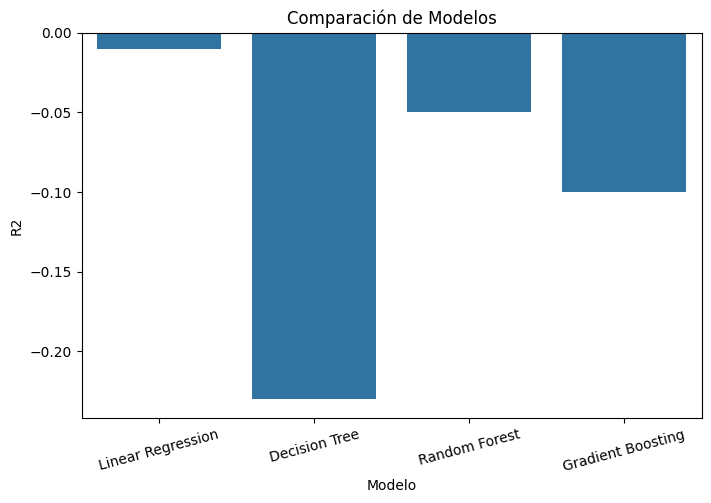

In [25]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Modelo',
    y='R2'
)

plt.title('Comparación de modelos')
plt.xticks(rotation=15)

plt.show()



# 14. Importancia de variables


In [26]:

rf_model.fit(X_train, y_train)

model = rf_model.named_steps['model']

feature_importances = pd.DataFrame({
    'Variable': numeric_features,
    'Importancia': model.feature_importances_[:len(numeric_features)]
})

feature_importances = feature_importances.sort_values(
    by='Importancia',
    ascending=False
)

feature_importances


,Variable,Importancia
4,population,0.150245
5,renewable_energy_pct,0.128013
1,co2_emissions_tons_capita,0.123448
7,forest_area_pct,0.120439
3,rainfall_mm,0.117523
2,sea_level_rise_mm,0.104369
0,year,0.082872
6,extreme_weather_events,0.068594


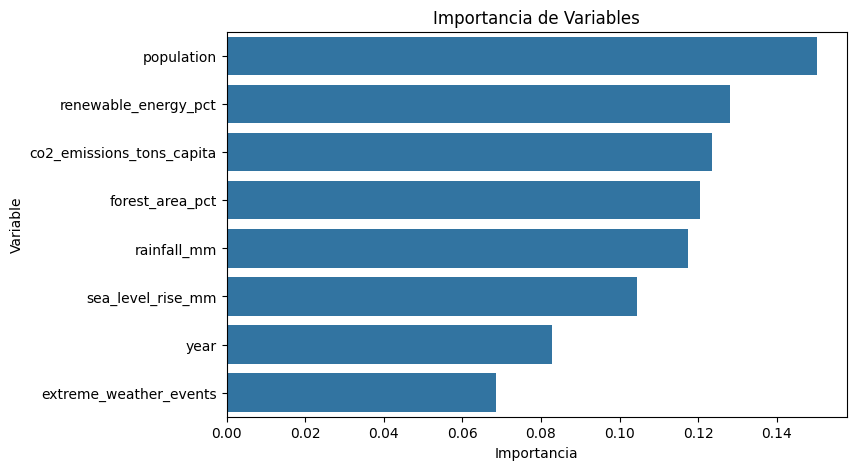

In [27]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importances,
    x='Importancia',
    y='Variable'
)

plt.title('Importancia de variables')

plt.show()


# 15. Interpretación de resultados

1. La variable más importante fue la población, con una importancia de 0.150, lo que indica que el crecimiento poblacional podría estar relacionado con cambios en la temperatura.
2. El porcentaje de energía renovable obtuvo una importancia de 0.128, mostrando que las prácticas energéticas tienen impacto en las variables climáticas.
3. Las emisiones de CO₂ per cápita alcanzaron una importancia de 0.123, confirmando su relación con el cambio climático.
Variables ambientales como el área forestal y la precipitación también mostraron influencia relevante en el comportamiento de la temperatura.

## Evaluación de modelos supervisados

Se compararon cuatro modelos de aprendizaje supervisado:

| Modelo            | RMSE | MAE  | R²    |
| ----------------- | ---- | ---- | ----- |
| Regresión Lineal  | 8.38 | 7.12 | -0.01 |
| Árbol de Decisión | 9.24 | 7.71 | -0.23 |
| Random Forest     | 8.54 | 7.21 | -0.05 |
| Gradient Boosting | 8.71 | 7.20 | -0.10 |

1. El modelo con mejor desempeño fue la Regresión Lineal, obteniendo el menor error RMSE (8.38) y el mejor valor R² (-0.01) entre los modelos evaluados.
2. El Árbol de Decisión presentó el peor rendimiento, con un RMSE de 9.24 y un R² de -0.23, indicando baja capacidad predictiva.
3. Los modelos Random Forest y Gradient Boosting lograron resultados intermedios, con errores cercanos a 8.5 y valores negativos de R².
4. Los valores negativos de R² indican que los modelos no lograron explicar adecuadamente la variabilidad de la temperatura promedio, lo que sugiere que las variables actuales no son suficientes para realizar predicciones altamente precisas.

# Conclusiones de resultados

## División de los datos

El dataset fue dividido en:

800 registros para entrenamiento (80%)
200 registros para prueba (20%)

Esta división permitió entrenar los modelos con una cantidad suficiente de datos y evaluar su rendimiento con información no vista previamente.


Los resultados muestran que existe relación entre las variables ambientales y el comportamiento climático; sin embargo, los modelos no alcanzaron un alto poder predictivo debido a las limitaciones del dataset y la complejidad del fenómeno climático.

A pesar de ello, el análisis permitió identificar variables importantes como población, emisiones de CO₂ y energía renovable, las cuales pueden ser relevantes para futuros estudios sobre cambio climático.

## importancia de variables

Importancia de Variables

Las variables con mayor influencia en las predicciones fueron:

| Variable                  | Importancia |
| ------------------------- | ----------- |
| population                | 0.150       |
| renewable_energy_pct      | 0.128       |
| co2_emissions_tons_capita | 0.123       |
| forest_area_pct           | 0.120       |
| rainfall_mm               | 0.118       |
